# Annotation listing and navigation

This notebook imports pUC19 from a GenBank file, loads its feature annotations,
and demonstrates two ways to work with them:

1. **Without a viewer** — query annotations directly from a `SequenceGraph` (preferred).
2. **With a widget** — navigate to a feature and add highlights interactively.

In [1]:
import os
import tempfile
import gen

## Import pUC19

Create a fresh in-memory repository and import a GenBank file.

In [2]:
# Adjust this path if running from outside the project root.
FIXTURE = os.path.abspath("../../fixtures/puc19.gb")

tmp = tempfile.mkdtemp()
repo = gen.Repository(os.path.join(tmp, ".gen"))
repo.import_genbank(FIXTURE)

sg = repo.get_sequence_graphs()[0]
print("Sequence graph:", sg.name)


Sequence graph: sequence-222046-


## List annotations without opening a viewer

`SequenceGraph.list_annotations()` reads persisted annotations directly from the
database — no widget required.  This is the preferred way to programmatically
inspect, filter, or iterate over features stored in the graph.

In [3]:
anns = sg.list_annotations()
print(f"{len(anns)} annotations stored in graph")
for a in anns:
    print(a)


21 annotations stored in graph
Annotation(name="Amp-R", track="GenBank default/reference/sequence-222046-", len=20)
Annotation(name="AmpR", track="GenBank default/reference/sequence-222046-", len=861)
Annotation(name="AmpR promoter", track="GenBank default/reference/sequence-222046-", len=105)
Annotation(name="CAP binding site", track="GenBank default/reference/sequence-222046-", len=22)
Annotation(name="L4440", track="GenBank default/reference/sequence-222046-", len=18)
Annotation(name="M13 Forward", track="GenBank default/reference/sequence-222046-", len=18)
Annotation(name="M13 Reverse", track="GenBank default/reference/sequence-222046-", len=17)
Annotation(name="M13 fwd", track="GenBank default/reference/sequence-222046-", len=17)
Annotation(name="M13 rev", track="GenBank default/reference/sequence-222046-", len=17)
Annotation(name="M13/pUC Forward", track="GenBank default/reference/sequence-222046-", len=23)
Annotation(name="M13/pUC Reverse", track="GenBank default/reference/seque

## Visualise with a widget

Call `.plot()` to open an interactive widget.  Annotation tracks from the GenBank
file are loaded automatically as a "Stored annotations" panel.

Additional GFF3 or BED files can be added at any time:

```python
fig.add_track_file("path/to/features.gff3")
```

To start with a blank canvas:

```python
fig.clear_all_annotations()
```

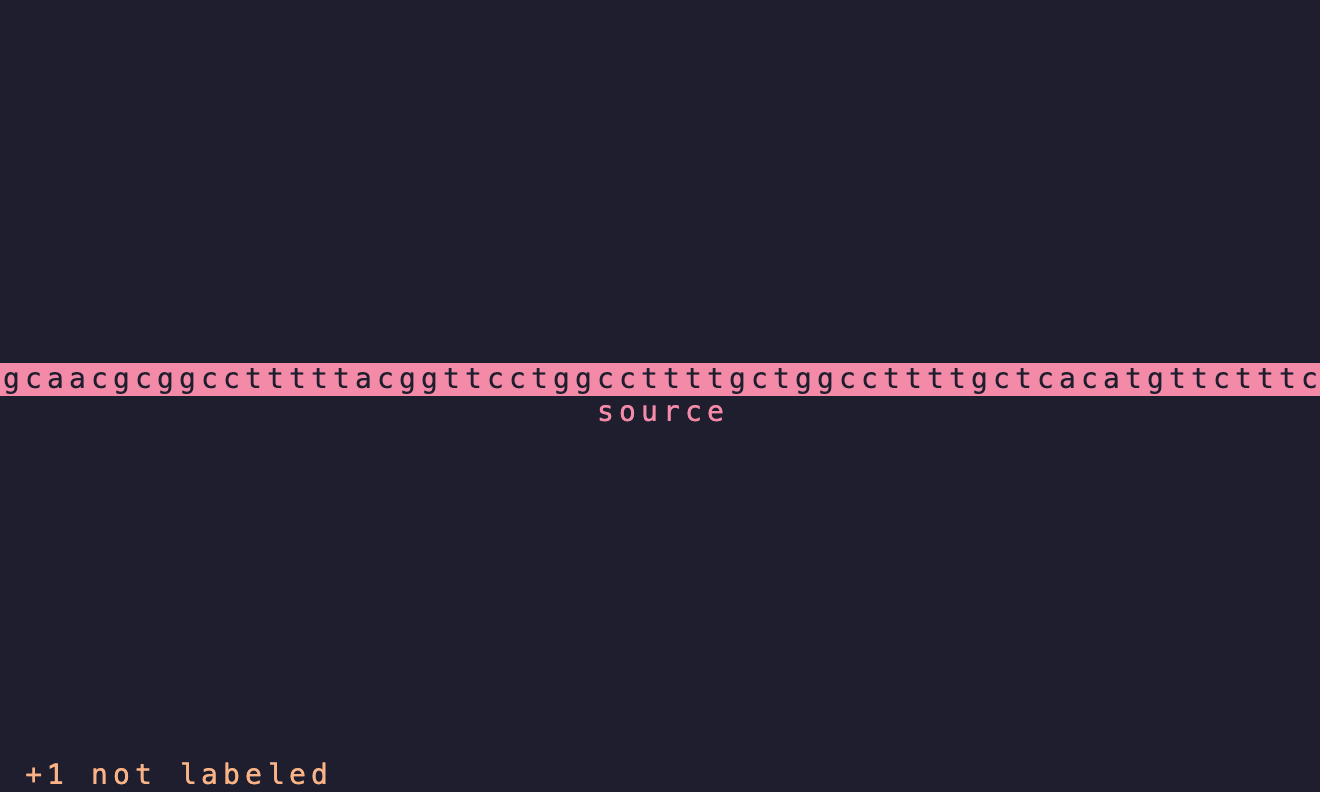

In [4]:
fig = sg.plot(rows=24)
fig


## List widget annotations

`fig.list_annotations()` reads persisted annotations directly from the database
(including those inherited from ancestor samples) — the same result as
`sg.list_annotations()`, but accessed through the widget handle.

In [5]:
anns = fig.list_annotations()
print(f"{len(anns)} annotations loaded")
for a in anns:
    print(a)

21 annotations loaded
Annotation(name="Amp-R", track="GenBank default/reference/sequence-222046-", len=20)
Annotation(name="AmpR", track="GenBank default/reference/sequence-222046-", len=861)
Annotation(name="AmpR promoter", track="GenBank default/reference/sequence-222046-", len=105)
Annotation(name="CAP binding site", track="GenBank default/reference/sequence-222046-", len=22)
Annotation(name="L4440", track="GenBank default/reference/sequence-222046-", len=18)
Annotation(name="M13 Forward", track="GenBank default/reference/sequence-222046-", len=18)
Annotation(name="M13 Reverse", track="GenBank default/reference/sequence-222046-", len=17)
Annotation(name="M13 fwd", track="GenBank default/reference/sequence-222046-", len=17)
Annotation(name="M13 rev", track="GenBank default/reference/sequence-222046-", len=17)
Annotation(name="M13/pUC Forward", track="GenBank default/reference/sequence-222046-", len=23)
Annotation(name="M13/pUC Reverse", track="GenBank default/reference/sequence-22204

## Navigate to the MCS

Filter for the MCS feature and navigate to it two ways:

* `widget.go_to(ann)` — left-pins the annotation start at column 12, no highlight
* `widget.show(ann)` — left-pins the annotation start and adds a highlight

In [6]:
# Left-pin the MCS start at column 12 from the left edge.
#mcs = next(a for a in anns if a.name == "MCS")
#fig.go_to(mcs)
#fig


In [7]:
# Or go somewhere and immediately add a highlight.
#pbla = next(a for a in anns if a.name == "AmpR promoter")

#fig.show(pbla)
#fig

## Search, filter, and navigate

Search for a sequence, wrap matches as `Annotation` objects, then navigate to one.

5 match(es) found


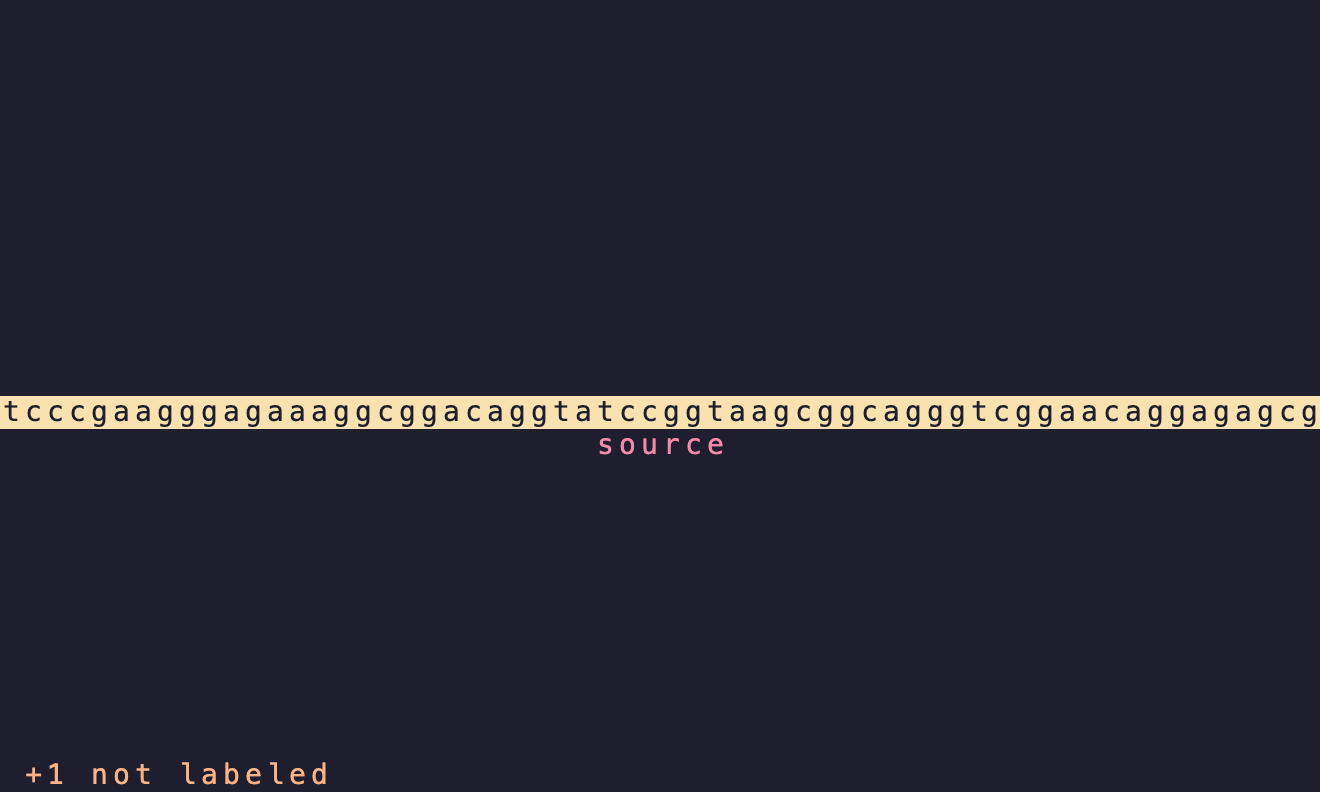

In [8]:
fig = sg.plot(rows=24)

# Search for Dcm methylation sites and add matches to the widget.
results = sg.search("CCWGG", "dna")

# The search query is a palindrome, so every match will also be a match on the opposite strand,
# filter by strand to prevent double labels:
matches = [locus for locus in results if locus.strand == "+"]
print(f"{len(matches)} match(es) found")

dcm_anns = [gen.Annotation(locus, f"Dcm ({i + 1} of {len(matches)})") for i, locus in enumerate(matches)]
fig.add_annotation_group(dcm_anns, "Dcm sites")

fig.go_to(matches[0])
fig

In [9]:
# The Dcm highlights added above are widget overlays, not stored in the graph.
# Navigate directly using the search results from the cell above.
print(f"{len(matches)} Dcm match(es) found")
fig.go_to(matches[0])
fig

5 Dcm match(es) found
